# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4099s 24us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

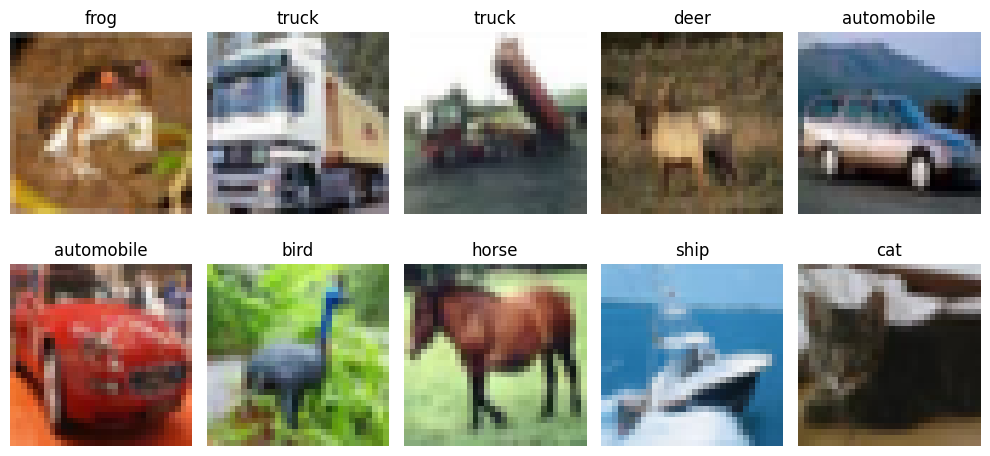

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [12]:
ann_model_v2 = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_v2_history = ann_model_v2.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - accuracy: 0.2601 - loss: 2.0065 - val_accuracy: 0.2952 - val_loss: 1.8974
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.3039 - loss: 1.8956 - val_accuracy: 0.3524 - val_loss: 1.8202
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accuracy: 0.3252 - loss: 1.8384 - val_accuracy: 0.3426 - val_loss: 1.8175
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.3378 - loss: 1.8104 - val_accuracy: 0.3738 - val_loss: 1.7692
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.3439 - loss: 1.7878 - val_accuracy: 0.3840 - val_loss: 1.7332
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.3596 - loss: 1.7620 - val_accuracy: 0.3844 - val_loss: 1.7214
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.3604 - loss: 1.7506 - val_accuracy: 0.4008 - val_loss: 1.7031
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 59ms/step - accuracy: 0.3696 - loss: 1.7277 - 

In [15]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)
ann_v2_test_loss, ann_v2_test_acc = ann_model_v2.evaluate(x_test_flat, y_test)
print("ANN v2 (deeper) Test Accuracy:", ann_v2_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4197 - loss: 1.6359
ANN Test Accuracy: 0.4196999967098236
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4275 - loss: 1.6267
ANN v2 (deeper) Test Accuracy: 0.42750000953674316


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [19]:
from tensorflow.keras.callbacks import EarlyStopping

cnn_model_v2 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

cnn_history_es = cnn_model_v2.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 112ms/step - accuracy: 0.4403 - loss: 1.5829 - val_accuracy: 0.5442 - val_loss: 1.3116
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 111ms/step - accuracy: 0.5823 - loss: 1.1851 - val_accuracy: 0.5506 - val_loss: 1.2286
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 114ms/step - accuracy: 0.6461 - loss: 1.0089 - val_accuracy: 0.6740 - val_loss: 0.9241
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 111ms/step - accuracy: 0.6860 - loss: 0.8920 - val_accuracy: 0.6420 - val_loss: 1.0203
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 112ms/step - accuracy: 0.7220 - loss: 0.7956 - val_accuracy: 0.6270 - val_loss: 1.0949
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 111ms/step - accuracy: 0.7425 - loss: 0.7324 - val_accuracy: 0.7260 - val_loss: 0.8031
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 110ms/step - accuracy: 0.7641 - loss: 0.6735 - val_accuracy: 0.7090 - val_loss: 0.8425
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 111ms/step - accuracy: 0.7807 - loss: 0

In [20]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

cnn_v2_test_loss, cnn_v2_test_acc = cnn_model_v2.evaluate(x_test_norm, y_test)
print("CNN v2 (EarlyStopping) Test Accuracy:", cnn_v2_test_acc)
print("Stopped at epoch:", len(cnn_history_es.history['loss']))

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7353 - loss: 1.0447
CNN Test Accuracy: 0.7353000044822693
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7255 - loss: 0.8097
CNN v2 (EarlyStopping) Test Accuracy: 0.7254999876022339
Stopped at epoch: 11


## 📈 Compare Learning Curves

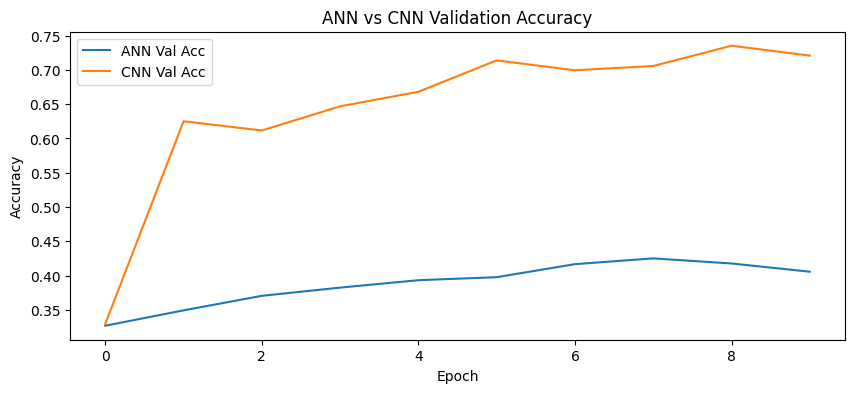

In [21]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [22]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 88ms/step - accuracy: 0.3516 - loss: 1.7677 - val_accuracy: 0.4698 - val_loss: 1.4599
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 84ms/step - accuracy: 0.4513 - loss: 1.5211 - val_accuracy: 0.5214 - val_loss: 1.3237
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 87ms/step - accuracy: 0.4877 - loss: 1.4271 - val_accuracy: 0.5312 - val_loss: 1.3073
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 85ms/step - accuracy: 0.5107 - loss: 1.3720 - val_accuracy: 0.5612 - val_loss: 1.2576
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 85ms/step - accuracy: 0.5306 - loss: 1.3211 - val_accuracy: 0.5926 - val_loss: 1.1363
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 85ms/step - accuracy: 0.5405 - loss: 1.2953 - val_accuracy: 0.5702 - val_loss: 1.1908
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 87ms/step - accuracy: 0.5548 - loss: 1.2612 - val_accuracy: 0.6218 - val_loss: 1.0744
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 59s 84ms/step - accuracy: 0.5601 - loss: 1.2412 - 

In [23]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6257 - loss: 1.0746
Augmented CNN Test Accuracy: 0.6256999969482422


# 📊 Final Comparison Table

In [24]:
comparison = pd.DataFrame({
    "Model": ["ANN (original)", "ANN v2 (deeper)", "CNN (original)",
              "CNN v2 (deeper + EarlyStopping)", "CNN + Augmentation"],
    "Test Accuracy": [ann_test_acc, ann_v2_test_acc, cnn_test_acc,
                       cnn_v2_test_acc, aug_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN (original),0.4197
1,ANN v2 (deeper),0.4275
2,CNN (original),0.7353
3,CNN v2 (deeper + EarlyStopping),0.7255
4,CNN + Augmentation,0.6257


313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step


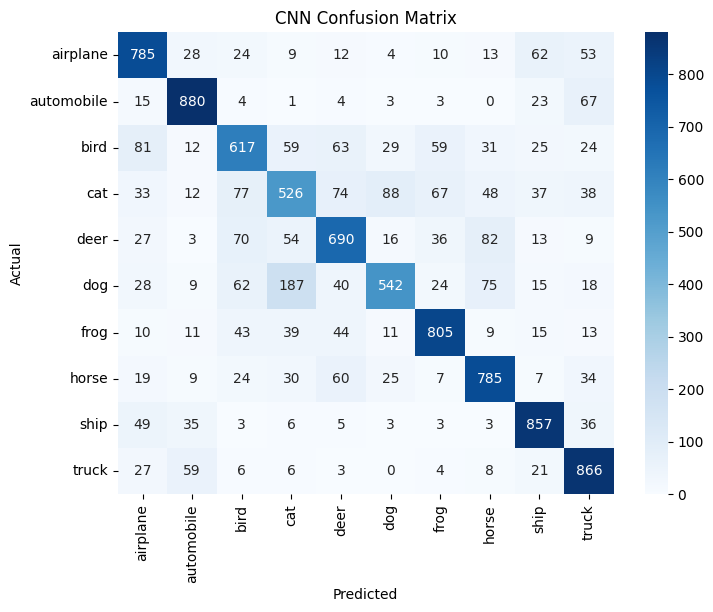

              precision    recall  f1-score   support

    airplane       0.73      0.79      0.76      1000
  automobile       0.83      0.88      0.86      1000
        bird       0.66      0.62      0.64      1000
         cat       0.57      0.53      0.55      1000
        deer       0.69      0.69      0.69      1000
         dog       0.75      0.54      0.63      1000
        frog       0.79      0.81      0.80      1000
       horse       0.74      0.79      0.76      1000
        ship       0.80      0.86      0.83      1000
       truck       0.75      0.87      0.80      1000

    accuracy                           0.74     10000
   macro avg       0.73      0.74      0.73     10000
weighted avg       0.73      0.74      0.73     10000



In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = cnn_model.predict(x_test_norm).argmax(axis=1)
y_true = y_test.flatten()

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- The ANN achieved only 41.97% test accuracy, and making it deeper (adding more Dense layers) only raised it to 42.75% — a negligible gain. This shows depth alone can't fix ANN's core limitation: flattening images into a 1D vector destroys spatial relationships between pixels.
- The CNN reached 73.53% test accuracy — roughly 31 points higher than either ANN, confirming that convolutional layers' ability to preserve and extract spatial features (edges, textures, shapes) is what actually drives performance on image data.
- Adding a 4th conv block with EarlyStopping (72.55%, stopped at epoch 11) performed slightly worse than the original 3-block CNN, suggesting the deeper architecture didn't have an advantage here — and that EarlyStopping correctly caught the point where validation loss stopped improving, saving unnecessary training time.
- Data augmentation (62.57%) actually underperformed the plain CNN in this experiment. With only 10 epochs and a smaller 2-block architecture (no BatchNorm), the model likely didn't have enough training time or capacity to benefit from the added variability in transformed images — a reminder that training strategies don't always help under limited epochs/capacity, and need to be paired with enough training time to show their benefit.
- The confusion matrix showed the CNN struggles most with animal classes, especially cat (55% F1) and dog (63% F1), frequently confusing the two — while vehicle classes like automobile (86% F1) and ship (83% F1) were classified far more reliably, due to their more rigid, consistent shapes.
- Overall, this project confirms CNN's clear advantage for image classification and shows that architecture changes and training strategies don't automatically improve results — they need to be evaluated empirically, as done here.